In [13]:
import copy
import h5py
import os
import numpy as np
import scipy
import sncosmo
from PIL import Image
import galsim
from astropy.cosmology import WMAP9 as cosmo
import matplotlib.pyplot as plt

from astropy.table import Table
# make sure lenstronomy is installed, otherwise install the latest pip version
try:
    import lenstronomy
except:
    get_ipython().system('pip install lenstronomy')
from astropy.io import fits
from astropy import wcs
import galsim

# lenstronomy module import
from lenstronomy.Util import image_util, data_util, util
import lenstronomy.Plots.plot_util as plot_util
from lenstronomy.SimulationAPI.sim_api import SimAPI
from lenstronomy.Plots.plot_util import coordinate_arrows, scale_bar
from lenstronomy.SimulationAPI.point_source_variability import PointSourceVariability

from astropy.table import Table
import sncosmo

import warnings

### Get supernova lightcurve magnitudes

In [14]:
def var_func(time, band): #band either desg, desi, desr
    obs = Table({'time': [time],
             'band': [band],          #filters we are observing in
             'gain': [1.],              #dw
             'skynoise': [0],           #depends on exposure time, but will be addig noise later in lenstronomy, could set to 0
             'zp': [30.],               # zero point, what corresponds to 0 flux in this image - pixel values to magnitudes
             'zpsys':['ab']})           # ab magnitudes, units of zero point

    model = sncosmo.Model(source='salt2')
    params = {'z': 0.01, 't0': 56200.0, 'x0':1.e-5, 'x1': 0.1, 'c': -0.1}

    lcs = sncosmo.realize_lcs(obs, model, [params])
    flux = np.array(lcs[0]['flux'])
    # print(lcs[0]['time'])
    # print(flux)
    zero_points = np.array(obs['zp'])
    magnitude = zero_points - 2.5 * np.log10(flux)
    # print(time,magnitude)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        np.seterr(all='ignore')  # suppress divide, invalid, etc.
        magnitude = obs['zp'][0] - 2.5 * np.log10(np.where(flux > 0, flux, np.nan))

        
    return magnitude
var_func_g = lambda t: var_func(t, 'lsstg')
var_func_r = lambda t: var_func(t, 'lsstr')
var_func_i = lambda t: var_func(t, 'lssti')



### Def plot image

In [37]:
def simulate_rgb(ConfigList, size, kwargs_numerics, time, source_x=0,source_y=0,returnsqrt = False):
    band_g, band_r, band_i = ConfigList
    kwargs_i_band = band_i.kwargs_single_band()
    kwargs_g_band = band_g.kwargs_single_band()
    kwargs_r_band = band_r.kwargs_single_band()
    #print(kwargs_b_band) #'pixel_scale' : kwargs_b_band['pixel_scale']
    # set number of pixels from pixel scale
    pixel_scale = kwargs_g_band['pixel_scale']
    numpix = int(round(size / pixel_scale))
    #kwargs_model['pixel_scale'] = kwargs_b_band['pixel_scale']
    sim_i = SimAPI(numpix=numpix, kwargs_single_band=kwargs_i_band, kwargs_model=kwargs_model_time_var)
    sim_g = SimAPI(numpix=numpix, kwargs_single_band=kwargs_g_band, kwargs_model=kwargs_model_time_var)
    sim_r = SimAPI(numpix=numpix, kwargs_single_band=kwargs_r_band, kwargs_model=kwargs_model_time_var)

    # return the ImSim instance. With this class instance, you can compute all the
    # modelling accessible of the core modules. See class documentation and other notebooks.
    imSim_i = sim_i.image_model_class(kwargs_numerics)
    imSim_g = sim_g.image_model_class(kwargs_numerics)
    imSim_r = sim_r.image_model_class(kwargs_numerics)


    # turn magnitude kwargs into lenstronomy kwargs
    kwargs_lens_light_g, kwargs_source_g, kwargs_ps_g = sim_g.magnitude2amplitude(kwargs_lens_light_mag_g, kwargs_source_mag_g, kwargs_ps_mag_g)
    kwargs_lens_light_r, kwargs_source_r, kwargs_ps_r = sim_g.magnitude2amplitude(kwargs_lens_light_mag_r, kwargs_source_mag_r, kwargs_ps_mag_r)
    kwargs_lens_light_i, kwargs_source_i, kwargs_ps_i = sim_r.magnitude2amplitude(kwargs_lens_light_mag_i, kwargs_source_mag_i, kwargs_ps_mag_i)

    ps_var_g = PointSourceVariability(source_x, source_y, var_func_g, numpix, kwargs_g_band, kwargs_model_time_var, kwargs_numerics,
                 kwargs_lens, kwargs_source_mag_g, kwargs_lens_light_mag_g, kwargs_ps_mag=kwargs_ps_mag_g)

    ps_var_r = PointSourceVariability(source_x, source_y, var_func_r, numpix, kwargs_r_band, kwargs_model_time_var, kwargs_numerics,
                 kwargs_lens, kwargs_source_mag_r, kwargs_lens_light_mag_r, kwargs_ps_mag=kwargs_ps_mag_r)

    ps_var_i = PointSourceVariability(source_x, source_y, var_func_i, numpix, kwargs_i_band, kwargs_model_time_var, kwargs_numerics,
                 kwargs_lens, kwargs_source_mag_i, kwargs_lens_light_mag_i, kwargs_ps_mag=kwargs_ps_mag_i)
    
    delays = ps_var_g.delays 
    kwargs_ps = ps_var_g.point_source_time(time)
    fluxes = (kwargs_ps[0]["point_amp"])
    print('DELAYS',delays) #,np.max(delays))

    image_g = ps_var_g.image_time(time=time)#imSim_b.image(kwargs_lens, kwargs_source_g, kwargs_lens_light_g, kwargs_ps_g)
    image_r = ps_var_r.image_time(time=time)#imSim_g.image(kwargs_lens, kwargs_source_r, kwargs_lens_light_r, kwargs_ps_r)
    image_i = ps_var_i.image_time(time=time)#imSim_r.image(kwargs_lens, kwargs_source_i, kwargs_lens_light_i, kwargs_ps_i)

    # add noise
    image_i += sim_i.noise_for_model(model=image_i)
    image_g += sim_g.noise_for_model(model=image_g)
    image_r += sim_r.noise_for_model(model=image_r)

    # and plot it

    img = np.zeros((image_g.shape[0], image_g.shape[1], 3), dtype=float)
    #scale_max=10000
    def _scale_max(image): 
        flat=image.flatten()
        flat.sort()
        scale_max = flat[int(len(flat)*0.95)]
        return scale_max
    if returnsqrt==True:
        img[:,:,0] = plot_util.sqrt(image_g, scale_min=0, scale_max=_scale_max(image_g))
        img[:,:,1] = plot_util.sqrt(image_r, scale_min=0, scale_max=_scale_max(image_r))
        img[:,:,2] = plot_util.sqrt(image_i, scale_min=0, scale_max=_scale_max(image_i))
    else:
        img[:,:,0] = image_i
        img[:,:,1] = image_g
        img[:,:,2] = image_r
        
    data_class = sim_i.data_class
    # #print(sim_r.psf_class.fwhm)
    # psf_i = sim_i.psf_class.kernel_point_source
    # psf_g = sim_g.psf_class.kernel_point_source
    # psf_r = sim_r.psf_class.kernel_point_source
    # psf = np.stack((psf_i,psf_g,psf_r))
    return img, data_class, ps_var_g, delays
    


### Camera kwargs

In [38]:
nbands = 3
nepochs = 15
bands = ['lsstg', 'lsstr', 'lssti']

times = np.arange(56150,56350,2)

from lenstronomy.SimulationAPI.ObservationConfig.DES import DES
#from lenstronomy.SimulationAPI.ObservationConfig.LSSTsingleobs import LSST
from lenstronomy.SimulationAPI.ObservationConfig.LSST import LSST

from lenstronomy.SimulationAPI.ObservationConfig.Euclid import Euclid
from lenstronomy.SimulationAPI.ObservationConfig.Roman import Roman

DES_g = DES(band='g', psf_type='GAUSSIAN', coadd_years=3)
DES_r = DES(band='r', psf_type='GAUSSIAN', coadd_years=3)
DES_i = DES(band='i', psf_type='GAUSSIAN', coadd_years=3)
des = [DES_g, DES_r, DES_i]

LSST_g = LSST(band='g', psf_type='GAUSSIAN', coadd_years=10)
LSST_r = LSST(band='r', psf_type='GAUSSIAN', coadd_years=10)
LSST_i = LSST(band='i', psf_type='GAUSSIAN', coadd_years=10)
lsst = [LSST_g, LSST_r, LSST_i]


Roman_g = Roman(band='F062', psf_type='PIXEL', survey_mode='wide_area')
Roman_r = Roman(band='F106', psf_type='PIXEL', survey_mode='wide_area')
Roman_i = Roman(band='F184', psf_type='PIXEL', survey_mode='wide_area')#'single_exposure')#'wide_area')
roman = [Roman_g, Roman_r, Roman_i]
LS4_g_band_obs = {'exposure_time': 15.,  # exposure time per image (in seconds)
                   'sky_brightness': 22.26,  # sky brightness (in magnitude per square arcseconds)
                   'magnitude_zero_point': 28.30,  # magnitude in which 1 count per second per arcsecond square is registered (in ADU's)
                   'num_exposures': 30,  # number of exposures that are combined
                   'seeing': 1.5,  # full width at half maximum of the PSF (if not specific psf_model is specified)
                   'psf_type': 'GAUSSIAN',  # string, type of PSF ('GAUSSIAN' and 'PIXEL' supported)
                   'kernel_point_source': None  # 2d numpy array, model of PSF centered with odd number of pixels per axis (optional when psf_type='PIXEL' is chosen)
                  }

LS4_r_band_obs = {'exposure_time': 15.,
                   'sky_brightness': 21.2,
                   'magnitude_zero_point': 28.13,
                   'num_exposures': 30,
                   'seeing': 1.5,
                   'psf_type': 'GAUSSIAN'}

LS4_i_band_obs = {'exposure_time': 15.,
                   'sky_brightness': 20.48,
                   'magnitude_zero_point': 27.79,
                   'num_exposures': 30,
                   'seeing': 1.5,
                   'psf_type': 'GAUSSIAN'}

LS4_camera = {'read_noise': 10,  # std of noise generated by read-out (in units of electrons)
               'pixel_scale': 1.0,  # scale (in arcseonds) of pixels
               'ccd_gain': 4.5  # electrons/ADU (analog-to-digital unit). A gain of 8 means that the camera digitizes the CCD signal so that each ADU corresponds to 8 photoelectrons.
              }
# lenstronomy provides these setting to be imported with the SimulationAPI.ObservationConfig routines.

kwargs_g_band_LS4 = util.merge_dicts(LS4_camera, LS4_g_band_obs)
kwargs_r_band_LS4 = util.merge_dicts(LS4_camera, LS4_r_band_obs)
kwargs_i_band_LS4 = util.merge_dicts(LS4_camera, LS4_i_band_obs)
kwargs_LS4 = [kwargs_g_band_LS4,kwargs_r_band_LS4,kwargs_i_band_LS4]

#Where to save plots and fits file
plotdir = 'outputs/SNsimplots_TD_noise'
storedir = 'outputs/SNsims_TD_noise'
# import NGC1300 jpg image and decompose it
import imageio.v2 as imageio
from scipy.ndimage import gaussian_filter
from lenstronomy.Cosmo.micro_lensing import einstein_radius
# find path to data
path = os.getcwd()
dirpath, _ = os.path.split(path)
module_path, _ = os.path.split(dirpath)

DELAYS [ 0.         11.74804232]
2
2
[nan nan]
DELAYS [ 0.         11.74804232]
2
2
[nan nan]
DELAYS [0.]
1
1
[nan]
DELAYS [ 0.         11.74804232]
2
2
[nan nan]
DELAYS [ 0.         11.74804232]
2
2
[nan nan]
DELAYS [ 0.         11.74804232]
2
2
[nan nan]
DELAYS [0.]
1
1
[nan]
DELAYS [0.]
1
1
[nan]
DELAYS [0.]
1
1
[nan]
DELAYS [ 0.         11.74804232]
2
2
[nan nan]
DELAYS [0.]
1
1
[nan]
DELAYS [ 0.         11.74804232]
2
2
[nan nan]
DELAYS [0.]
1
1
[nan]
DELAYS [ 0.         11.74804232]
2
2
[nan nan]
DELAYS [0.]
1
1
[nan]
DELAYS [0.]
1
1
[nan]
DELAYS [ 0.         11.74804232]
2
2
[1.88576876        nan]
DELAYS [0.]
1
1
[8.00224338]
DELAYS [ 0.         11.74804232]
2
2
[25.20699025         nan]
DELAYS [0.]
1
1
[55.85326601]
DELAYS [ 0.         11.74804232]
2
2
[90.65127655         nan]
DELAYS [0.]
1
1
[127.25129362]
DELAYS [0.]
1
1
[156.72017888]
DELAYS [ 0.         11.74804232]
2
2
[188.64971312  23.42105807]
DELAYS [ 0.         11.74804232]
2
2
[205.07573851 113.44981704]
DELAYS [ 0

ValueError: x and y must have same first dimension, but have shapes (100,) and (2,)

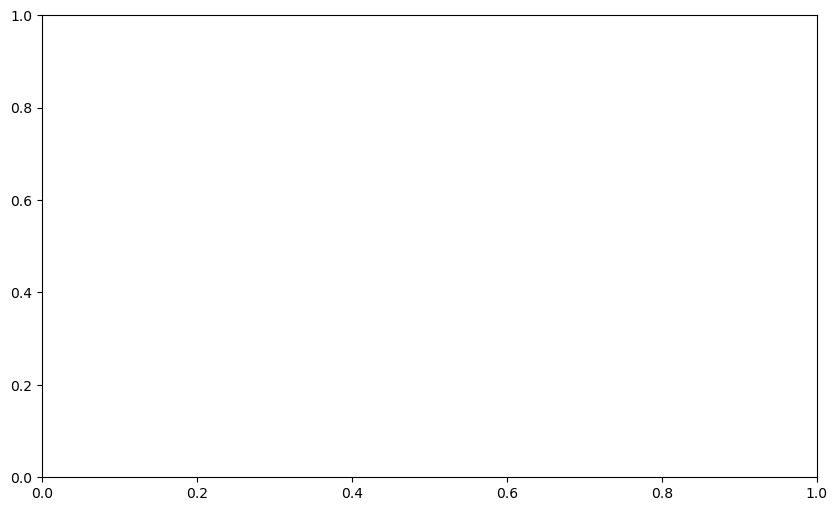

In [39]:
#ignore devide by 0 warning and astropy warning
import warnings
np.seterr(divide='ignore')  
warnings.filterwarnings("ignore", message="Astropy Cosmology is provided. Make sure your cosmology model is consistent with the cosmology_model argument.")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    # magnitude = zero_points - 2.5 * np.log10(flux)



f = h5py.File('lsst-altsched-1a-lowz.h5','r')
simitems = np.asarray(f['system']['block0_items'][()],dtype=str)
simdataall = f['system']['block0_values'][()]
# print(simdataall[0],simitems)
rtest_source = [0.944,0.766, 0.678, 0.967, 0.717]
rtest_lens = [0.410, 0.396, 0.344, 0.680, 0.056]
rtest_delay = [11.36, 9.07, 20.28, 1.82, 3.06]


# #This is where I match to that table I provided by redshift. You'll want to replace this with a search for the time delay parameter and match by that!
# indcatalog =[]
# for i in range(5):
#     indD = np.argwhere((np.abs(rtest_delay[i]-delta_t)<0.0005))
#     if i==0:
#         indcatalog=indD[:,0]
#     else:
#         indcatalog = np.hstack((indcatalog,indD[:,0]))

indcatalog = [146401] #, 134600, 
              #17462, 129533, 
              #96679, 158021,
              #124869, 36820,
              #21540, 210563]
# N: double, quad, double, quad, double, quad, double, quad, triple, double
#Target delay:  11.36, 11.36, 3.06, 3.06, 20.28, 20.28, 9.07, 9.07, 1.82, 1.82
#Max delay:  11.748042320638811, 11.597752391557174, 
            # 3.2590137441131444, 2.8998675262774922, 
            # 20.439694141425264, 20.574373570656064
            # 8.681846948273526, 9.566897731795187
            # 2.176213181824599, 2.2461588436004623
#Redshifts: z lens 0.41241541553482486 z source 0.9478742326589379, 
    #z lens 0.4185719867661402 z source 0.938835709387265,
    #z lens 0.05380463098441916 z source 0.7200284346083838,
    #z lens 0.05748563590541787 z source 0.7201234038050096, 
    #z lens 0.35053917396292883 z source 0.6728093548400655
    #z lens 0.3307544581867259 z source 0.6854050987893003
    #z lens 0.4051844880103184 z source 0.75831776773053
    #z lens 0.3765958346346411 z source 0.7782941179011835
    #z lens 0.6903449386733416 z source 0.9484084498118633
    #z lens 0.6628101878711817 z source 0.9690668769977538
    

for ind in indcatalog:
    simdata=simdataall[ind]
    z_lens = simdata[simitems == "zl"][0]
    z_source = simdata[simitems == "zs"][0]
    # print('z lens',z_lens,'z source',z_source)
    kwargs_model_time_var = {'lens_model_list': ['SIE', 'SHEAR'],  # list of lens models to be used
                'lens_light_model_list': ['SERSIC_ELLIPSE'],  # list of unlensed light models to be used
                'source_light_model_list': ['SERSIC_ELLIPSE'],#['INTERPOL'],  # list of extended source models to be used, here we used the interpolated real galaxy
                'point_source_model_list': ['SOURCE_POSITION'],  # list of point source models to be used
                'z_lens': z_lens, 
                         'z_source': z_source
    } 
    Dl = cosmo.angular_diameter_distance(simdata[simitems == "zl"][0]).value
    Ds = cosmo.angular_diameter_distance(simdata[simitems == "zs"][0]).value
    Dls = cosmo.angular_diameter_distance_z1z2(simdata[simitems == "zl"][0],simdata[simitems == "zs"][0]).value
 
    theta_E_sim = simdata[simitems == "theta_e"][0]
    lens_reff = simdata[simitems == "lensgal_reff"][0]
    lens_n = simdata[simitems == "lensgal_n"][0]
    lens_theta = simdata[simitems == "lensgal_theta"][0]
    lens_ellip = simdata[simitems == "lensgal_ellip"][0]
    s = galsim.Shear(e=lens_ellip, beta=lens_theta*galsim.degrees)
    lens_e1 = s.e1
    lens_e2 = s.e2
   
    lens_gamma = simdata[simitems == "gamma"][0]
    gamma_theta = simdata[simitems == "theta_gamma"][0]
    lens_g1 = np.sin(gamma_theta*np.pi/180)*lens_gamma
    lens_g2 = np.cos(gamma_theta*np.pi/180)*lens_gamma
    lens_x = simdata[simitems == "lensgal_x"][0]
    lens_y = simdata[simitems == "lensgal_y"][0]

    host_reff = simdata[simitems == "host_reff"][0]
    host_n = simdata[simitems == "host_n"][0]
    host_theta = simdata[simitems == "host_theta"][0]
    host_ellip = simdata[simitems == "host_ellip"][0]
    try:
        sh = galsim.Shear(e=host_ellip, beta=host_theta*galsim.degrees)
    except:
        continue
    host_e1 = sh.e1
    host_e2 = sh.e2
    host_x = simdata[simitems == "host_x"][0]
    host_y = simdata[simitems == "host_y"][0]
    sn_x = simdata[simitems == "snx"][0]
    sn_y = simdata[simitems == "sny"][0]

    #My failed attempts to extract a meaningful magnitude from whatever units Danny was using
    '''
    lens_amp = 22.5-2.5*np.log10(simdata[simitems == "lensgal_amplitude"][0])
    mu = -2.5*np.log(simdata[simitems == "lensgal_amplitude"][0])
    mag = mu - np.log10(2*np.pi*host_reff*60*60/180*np.pi*1e3)-36.57#mu - 5*np.log10(lens_reff/(Dl/60/60))-2.5*np.log10(2*np.pi)+10*np.log10(1+simdata[simitems == "zl"][0])
    print('MAG',mag,host_reff)
    print('VMAG',-2.5*np.log10(simdata[simitems == "lensgal_amplitude"][0])-48.6)
    host_amp = 22.5-2.5*np.log10(simdata[simitems == "host_amplitude"][0])
    print(str(simitems),'lens_amp',lens_amp,'host_amp',host_amp,simdata[simitems == "lensgal_amplitude"][0])
    '''
    
    magdiff = 2.5*(np.log10(simdata[simitems == "lensgal_amplitude"][0])-np.log10(simdata[simitems == "host_amplitude"][0]))
   
    magdiffps = 2.5*(np.log10(simdata[simitems == "lensgal_amplitude"][0])-np.log10(simdata[simitems == "transient_amplitude"][0]))
  
    sig = simdata[simitems == "sigma"][0]
    theta_E = 4*np.pi*(sig/3e5)**2*Dls/Ds*180/np.pi*60*60
    M0=1.9*(sig/200)**5.1*1e8
    Mstar= 10**((np.log10(M0)-7.45)/1.05)*1e11
 
    radius = einstein_radius(Mstar, Dl*1e6, Ds*1e6)

    kwargs_lens = [
        {'theta_E': theta_E, 'e1': lens_e1, 'e2': lens_e2, 'center_x': lens_x, 'center_y': lens_y},  # SIE model
        {'gamma1': lens_g1, 'gamma2': lens_g2, 'ra_0': 0, 'dec_0': 0}  # SHEAR model
    ]
    # lens light
    kwargs_lens_light_mag_g = [{'magnitude': 23, 'R_sersic': lens_reff, 'n_sersic': lens_n, 'e1': lens_e1, 'e2': lens_e2, 'center_x': lens_x, 'center_y': lens_y}]
    # source light
    kwargs_source_mag_g = [{'magnitude': 23, 'R_sersic': host_reff, 'n_sersic': host_n, 'e1': host_e1, 'e2': host_e2, 'center_x': host_x, 'center_y': host_y}]

    # point source
    kwargs_ps_mag_g = [{'magnitude': 23, 'ra_source': sn_x, 'dec_source': sn_y}]

   
    # and now we define the colors of the other two bands

    # r-band
    g_r_source = 1  # color mag_g - mag_r for source
    g_r_lens = -1  # color mag_g - mag_r for lens light
    g_r_ps = 0
    kwargs_lens_light_mag_r = copy.deepcopy(kwargs_lens_light_mag_g)
    kwargs_lens_light_mag_r[0]['magnitude'] -= g_r_lens

    kwargs_source_mag_r = copy.deepcopy(kwargs_source_mag_g)
    kwargs_source_mag_r[0]['magnitude'] -= g_r_source

    kwargs_ps_mag_r = copy.deepcopy(kwargs_ps_mag_g)
    kwargs_ps_mag_r[0]['magnitude'] -= g_r_ps


    # i-band
    g_i_source = 2
    g_i_lens = -2
    g_i_ps = 0
    kwargs_lens_light_mag_i = copy.deepcopy(kwargs_lens_light_mag_g)
    kwargs_lens_light_mag_i[0]['magnitude'] -= g_i_lens

    kwargs_source_mag_i = copy.deepcopy(kwargs_source_mag_g)
    kwargs_source_mag_i[0]['magnitude'] -= g_i_source

    kwargs_ps_mag_i = copy.deepcopy(kwargs_ps_mag_g)
    kwargs_ps_mag_i[0]['magnitude'] -= g_i_ps


    # here we define the numerical options used in the ImSim module. 
    # Have a look at the ImageNumerics class for detailed descriptions.
    # If not further specified, the default settings are used.
    kwargs_numerics = {'point_source_supersampling_factor': 1}

    # Hack hard coded solution to get out PSF on line 52 of ~/.conda/envs/scarlet/lib/python3.10/site-packages/lenstronomy/Data/psf.py 
    #to get out PSF image!
    size = 6. # width of the image in units of arc seconds

    #img_des, coords_des, sim_b = simulate_rgb(des, size=size, kwargs_numerics=kwargs_numerics)

    light_curves = []
    for indt,time in enumerate(times):
        img_lsst, coords_lss, ps_var_g_lss, delays = simulate_rgb(lsst, size=size, kwargs_numerics=kwargs_numerics,time=time,source_x=sn_x,source_y=sn_y,returnsqrt=False)
        print(len(delays))
        # img_roman, coords_roman, ps_var_g_roman = simulate_rgb(roman, size=size, kwargs_numerics=kwargs_numerics,time=time, source_x=sn_x,source_y=sn_y,returnsqrt=False)
        # #print(psf_lsst,psf_roman)
        # img_LS4, coords_LS4, ps_var_g_LS4 = simulate_rgb_LS4(size=size, kwargs_LS4=kwargs_LS4,time=time, source_x=sn_x,source_y=sn_y,returnsqrt=False) 
        # # if indt==0:
        # #     vminlsst=np.min(img_lsst)
        # #     vmaxlsst= 1.5*np.max(img_lsst)
        # #     vminLS4=np.min(img_LS4)
        # #     vmaxLS4= 1.5*np.max(img_LS4)
        # #     vminroman=np.min(img_roman)
        # #     vmaxroman= 1.5*np.max(img_roman)
        # # print(vmaxlsst)
        # # img_lsst, coords_lss, delays, magnitudes = simulate_rgb(lsst, size=size, kwargs_numerics=kwargs_numerics,time=time)
        # # img_roman, coords_roman, delays, magnitudes = simulate_rgb(roman, size=size, kwargs_numerics=kwargs_numerics,time=time)

        num_images = len(ps_var_g_lss.delays)
        print(num_images)
        kwargs_ps = ps_var_g_lss.point_source_time(time)
        fluxes = kwargs_ps[0]["point_amp"]
        print(fluxes)
            
        light_curves.append(fluxes)

    plt.figure(figsize=(10, 6))
    for i, curve in enumerate(light_curves):
        plt.plot(times, curve, label=f'Image {i+1}')
        
    plt.gca().invert_yaxis()
    plt.xlabel('Time (days)')
    plt.ylabel('Apparent Magnitude')
    plt.title('Lensed Supernova Light Curves (Image-separated)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()










In [ ]:
# %run simulating_different_telescopes-SNsims_multiepoch.py